In [1]:
import json 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from collections import Counter, defaultdict

In [2]:
def load_json_data(path_file):
    data = []
    with open(path_file, mode="r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))

    return data

In [3]:
train_data = load_json_data("../data/raw/PhoNER_COVID19/word/train_word.json")
dev_data = load_json_data("../data/raw/PhoNER_COVID19/word/dev_word.json")
test_data = load_json_data("../data/raw/PhoNER_COVID19/word/test_word.json")

In [4]:
print(train_data[0])

{'words': ['Đồng_thời', ',', 'bệnh_viện', 'tiếp_tục', 'thực_hiện', 'các', 'biện_pháp', 'phòng_chống', 'dịch_bệnh', 'COVID', '-', '19', 'theo', 'hướng_dẫn', 'của', 'Bộ', 'Y_tế', '.'], 'tags': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORGANIZATION', 'I-ORGANIZATION', 'O']}


In [5]:
print(len(train_data))
print(len(test_data))
print(len(dev_data))

5027
3000
2000


### Kiểm tra dữ liệu không hợp lệ:
- Độ dài từ khác độ dài tag

In [6]:
invalid = []

for i, sample in enumerate(train_data):
    words, tags = sample["words"], sample['tags']
    if len(words) != len(tags):
        invalid.append(i)

print(len(invalid))

0


### Phân bố nhãn

In [7]:
def entity_distribution(data):
    tag_counter = Counter()
    entity_counter = Counter()

    for sample in data:
        for tag in sample["tags"]:
            tag_counter[tag] += 1
            if tag.strip() != "O":
                entity = tag.split("-")[-1]
                entity_counter[entity] += 1
    
    df = pd.DataFrame.from_dict(entity_counter, orient="index", columns=["count"]).reset_index()
    df = df.rename(columns={"index": "entity"})
    df = df.sort_values("count", ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=df, x="entity", y="count", palette="viridis")
    plt.title("Entity Type Distribution")
    plt.xticks(rotation=90)
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return tag_counter, entity_counter

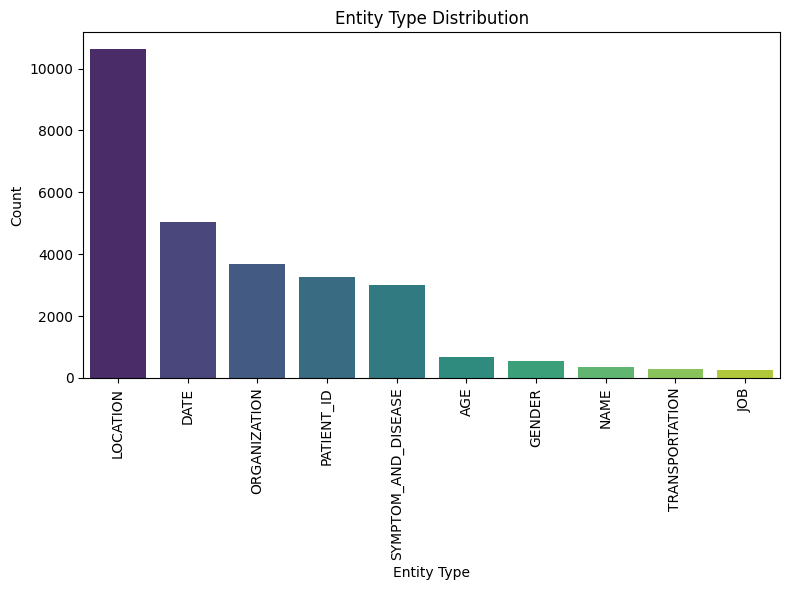

In [8]:
tag_counter, entity_counter = entity_distribution(train_data)

In [9]:
tag_counter

Counter({'O': 104750,
         'B-LOCATION': 5398,
         'I-LOCATION': 5242,
         'B-PATIENT_ID': 3240,
         'B-DATE': 2549,
         'I-ORGANIZATION': 2545,
         'I-DATE': 2500,
         'I-SYMPTOM_AND_DISEASE': 1552,
         'B-SYMPTOM_AND_DISEASE': 1439,
         'B-ORGANIZATION': 1137,
         'B-AGE': 682,
         'B-GENDER': 542,
         'B-NAME': 349,
         'B-TRANSPORTATION': 226,
         'B-JOB': 205,
         'I-TRANSPORTATION': 67,
         'I-JOB': 62,
         'I-NAME': 13,
         'I-PATIENT_ID': 11,
         'I-AGE': 2})

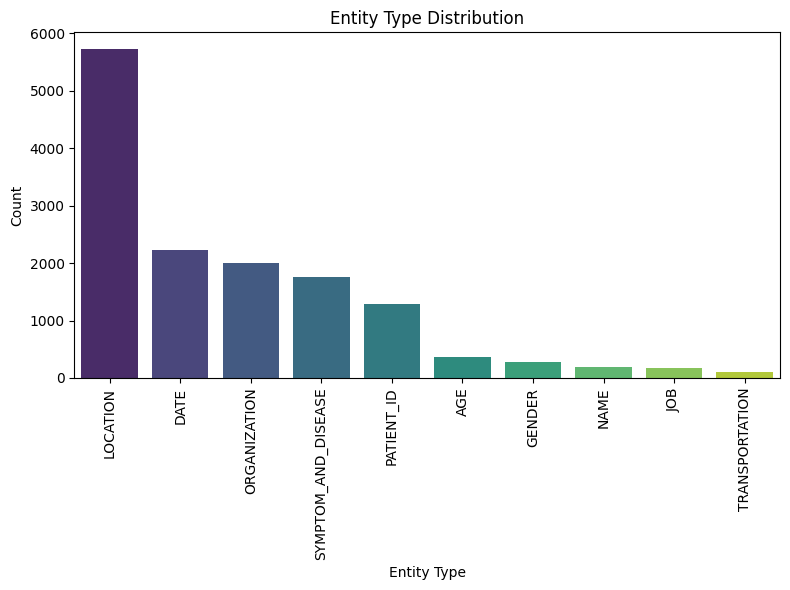

In [10]:
tag_counter, entity_counter = entity_distribution(dev_data)

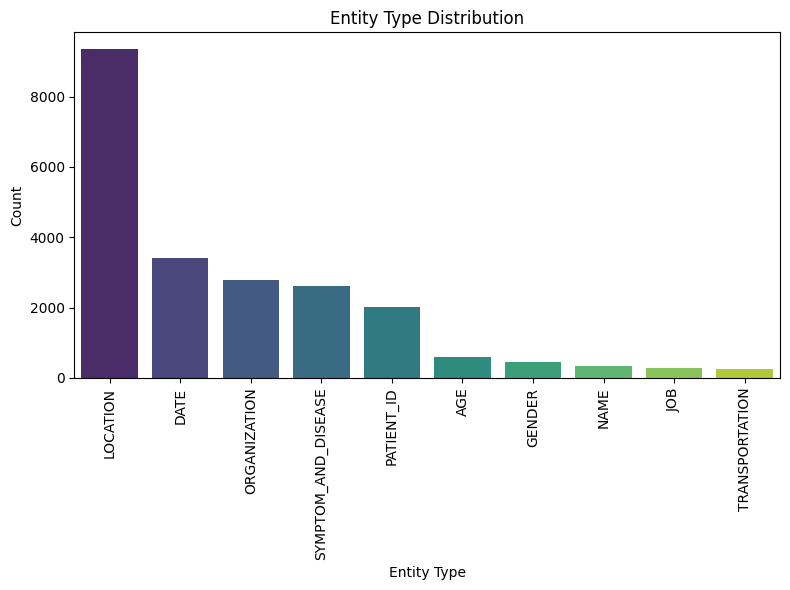

In [11]:
tag_counter, entity_counter = entity_distribution(test_data)

Gặp tình trạng mất cân bằng nặng giữa các thực thể => xem xét phương pháp điều chỉnh  
Phân phối thực thể giống nhau ở cả 3 tập 

### Phân phối độ dài câu 

In [12]:
def sentence_length_distribution(data):
    lengths = [len(sample["words"]) for sample in data]
    print(f"\nĐộ dài câu trung bình: {np.mean(lengths):.2f}")
    print(f"Max: {max(lengths)}, Min: {min(lengths)}")

    plt.figure(figsize=(8, 4))
    sns.histplot(lengths, bins=40, kde=True)
    plt.title("Sentence Length Distribution")
    plt.xlabel("Sentence Length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    return lengths


Độ dài câu trung bình: 26.36
Max: 161, Min: 6


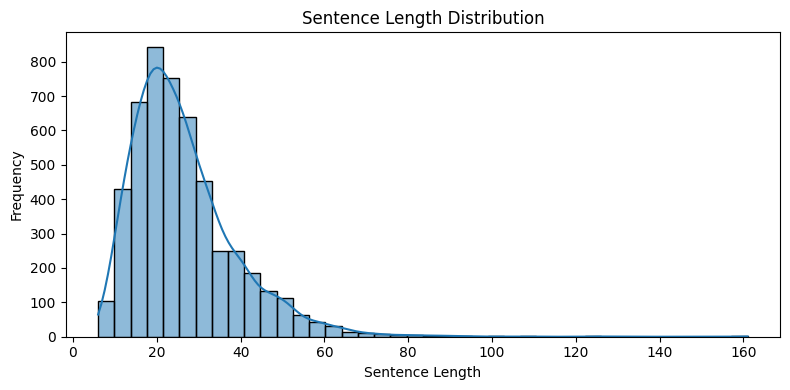

In [14]:
train_lengths = sentence_length_distribution(train_data)

=> Tập atrung trong khoảng < 80. Trung bình đạt 28.14 max 160 => dựa vào đây chọn max_seq trong LSTM


Độ dài câu trung bình: 28.56
Max: 162, Min: 7


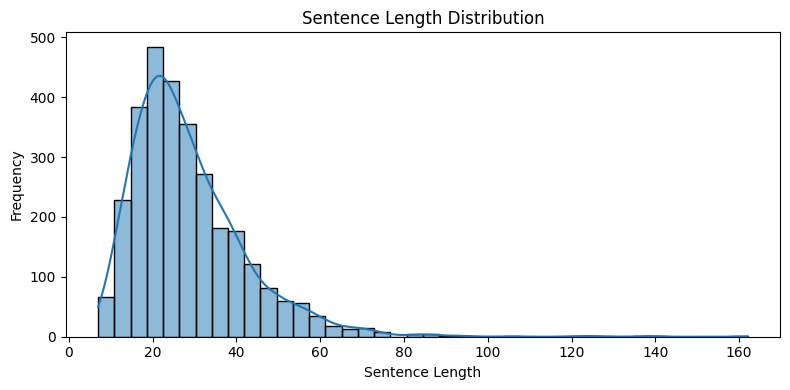

In [15]:
test_lengths = sentence_length_distribution(test_data)


Độ dài câu trung bình: 28.14
Max: 138, Min: 7


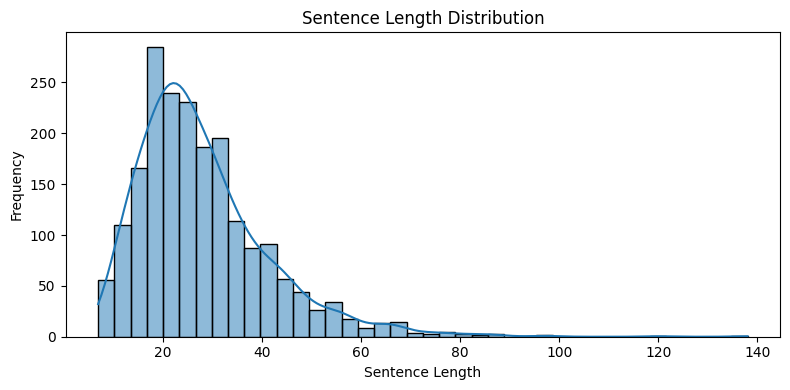

In [16]:
dev_lengths = sentence_length_distribution(dev_data)

Phân phối chiều dài nhãn tương tự nhau ở cả 3 tập dữ liệu

### Phân tích độ dài các thực thể 

In [17]:
def entity_len_distribution(data):
    span_lengths = defaultdict(list)
    
    for sample in data:
        current_entity = None
        current_length = 0
        for tag in sample["tags"]:
            if tag.startswith("B-"):
                if current_entity:
                    span_lengths[current_entity].append(current_length)
                current_entity = tag.split("-")[1]
                current_length = 1
            elif tag.startswith("I-") and current_entity:
                current_length += 1
            else:
                if current_entity:
                    span_lengths[current_entity].append(current_length)
                    current_entity = None
                    current_length = 0
    records = []
    for ent, lengths in span_lengths.items():
        for l in lengths:
            records.append({"entity": ent, "length": l})

    df = pd.DataFrame(records)

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x="entity", y="length", palette="mako")
    plt.title("Entity Span Lengths by Type")
    plt.xticks(rotation=90)
    plt.xlabel("Entity Type")
    plt.ylabel("Span Length (#tokens)")
    plt.tight_layout()
    plt.show()

    print("\nAvg span length by entity:")
    print(df.groupby("entity")["length"].mean())
    

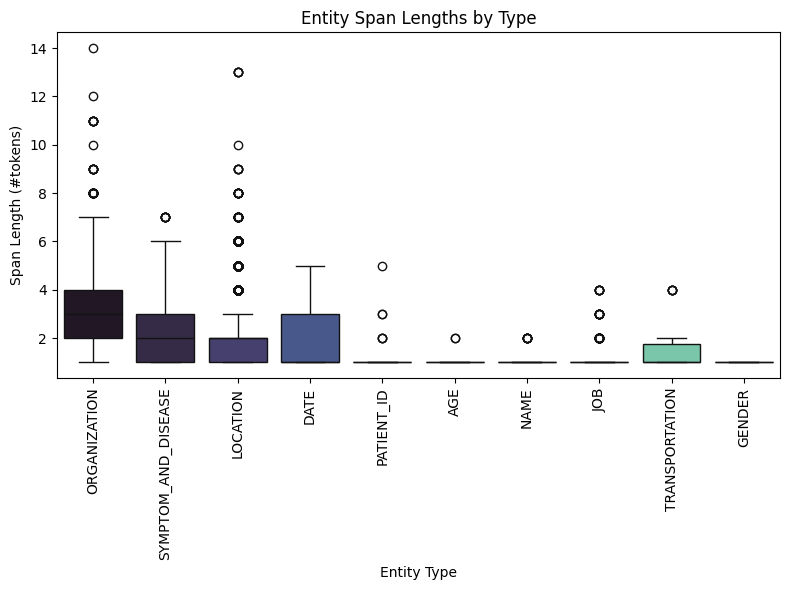


Avg span length by entity:
entity
AGE                    1.002933
DATE                   1.980377
GENDER                 1.000000
JOB                    1.302439
LOCATION               1.972513
NAME                   1.023529
ORGANIZATION           3.235658
PATIENT_ID             1.003396
SYMPTOM_AND_DISEASE    2.077191
TRANSPORTATION         1.296460
Name: length, dtype: float64


In [18]:
entity_len_distribution(train_data)

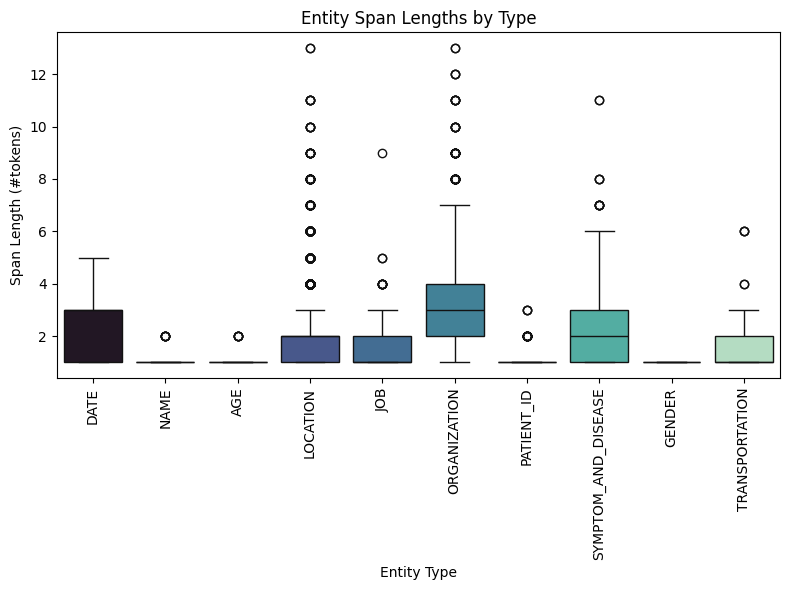


Avg span length by entity:
entity
AGE                    1.010309
DATE                   2.058041
GENDER                 1.000000
JOB                    1.658960
LOCATION               2.108617
NAME                   1.022951
ORGANIZATION           3.613784
PATIENT_ID             1.013473
SYMPTOM_AND_DISEASE    2.305996
TRANSPORTATION         1.357513
Name: length, dtype: float64


In [19]:
entity_len_distribution(test_data)

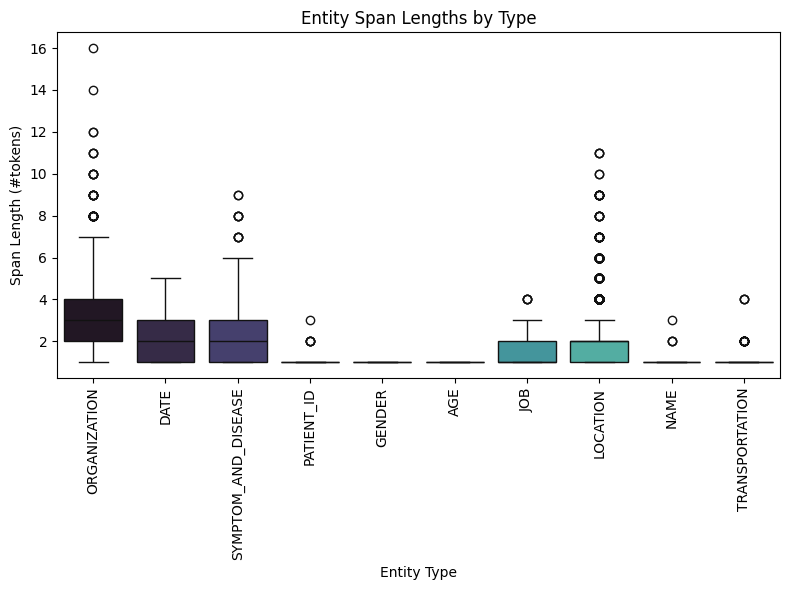


Avg span length by entity:
entity
AGE                    1.000000
DATE                   2.013599
GENDER                 1.000000
JOB                    1.371212
LOCATION               2.093716
NAME                   1.026738
ORGANIZATION           3.639344
PATIENT_ID             1.005486
SYMPTOM_AND_DISEASE    2.282723
TRANSPORTATION         1.287356
Name: length, dtype: float64


In [20]:
entity_len_distribution(dev_data)